# ?? Task 1: RetailPulse Forecast ? Sales & Demand Forecasting for Businesses
### Track: Machine Learning (`ML`) | Internship ID: `FIT/AUG26/ML10465` | Repository: `FUTURE_ML_01`

---
### **Project Overview & Objectives**
In enterprise retail environments, inaccurate demand forecasting causes severe operational friction: stockouts during holiday peaks lead to lost revenue and customer churn, while overstocking leads to excessive inventory holding costs and markdown depreciation.

**RetailPulse Forecast** is an end-to-end Machine Learning forecasting pipeline built for multi-store, multi-department enterprise demand planning.

#### **Key Capabilities:**
1. **Strict Chronological Data Splitting**: Zero look-ahead bias across Train (70%), Validation (15%), and Test (15%) horizons.
2. **Time-Based Feature Engineering**: Multi-lag horizons ($t-1, t-2, t-4, t-8, t-12, t-52$), rolling window statistics ($4, 8, 12, 26, 52$ weeks), exponential moving averages, cyclical calendar encodings, holiday indicators, and promotional markdowns.
3. **Multi-Model Competitive Benchmarking**: Naive Lag-1, Seasonal Lag-52, 4W Moving Average, Ridge Regression, Random Forest, LightGBM, and XGBoost.
4. **Comprehensive Evaluation**: MAE, RMSE, MAPE, WAPE, and $R^2$ metrics with sliced error analysis.
5. **Inventory Planning Translation**: Safety stock and Dynamic Reorder Point (ROP) calculation at 95% service level.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

sys.path.append(os.path.abspath('..'))

from src.data_loader import save_and_load_dataset
from src.features import create_time_features, create_lag_and_rolling_features, prepare_feature_matrix
from src.models import get_model_registry, chronological_split
from src.evaluate import compute_metrics, analyze_error_by_segment

print("? Environment loaded successfully. Python:", sys.version.split()[0])

? Environment loaded successfully. Python: 3.12.5


## 1. Data Ingestion & Exploratory Data Analysis (EDA)

In [2]:
data_path = os.path.join('..', 'data', 'retail_store_sales.csv')
df = save_and_load_dataset(data_path)
print("Dataset Shape:", df.shape)
display(df.head(10))
display(df.describe().round(2))

[DataLoader] Dataset loaded from ..\data\retail_store_sales.csv (Shape: (5490, 15))
Dataset Shape: (5490, 15)


,Date,Store_ID,Store_Type,Store_Size,Dept_ID,Dept_Name,Weekly_Sales,IsHoliday,Holiday_Name,Markdown_Discount,Promotional_Flag,Temperature,Fuel_Price,CPI,Unemployment_Rate
0,2021-01-01,1,A,150000,1,Electronics,48356.88,0,NaN,0.00,0,35.7,3.139,210.248,7.52
1,2021-01-08,1,A,150000,1,Electronics,48052.62,0,NaN,0.00,0,44.5,3.144,210.068,7.49
2,2021-01-15,1,A,150000,1,Electronics,49517.76,0,NaN,1154.62,1,36.4,3.281,210.599,7.49
3,2021-01-22,1,A,150000,1,Electronics,42339.50,0,NaN,0.00,0,36.5,3.323,211.174,7.39
4,2021-01-29,1,A,150000,1,Electronics,50128.12,0,NaN,0.00,0,40.1,3.340,210.432,7.45
5,2021-02-05,1,A,150000,1,Electronics,45891.73,0,NaN,0.00,0,37.8,3.337,210.570,7.49
6,2021-02-12,1,A,150000,1,Electronics,55328.80,1,Super Bowl,1705.51,1,31.6,3.341,211.614,7.57
7,2021-02-19,1,A,150000,1,Electronics,46959.04,0,NaN,0.00,0,48.6,3.483,211.345,7.51
8,2021-02-26,1,A,150000,1,Electronics,48078.43,0,NaN,0.00,0,46.8,3.641,210.864,7.62
9,2021-03-05,1,A,150000,1,Electronics,48593.30,0,NaN,4259.33,1,48.5,3.641,211.508,7.31


,Date,Store_ID,Store_Size,Dept_ID,Weekly_Sales,IsHoliday,Markdown_Discount,Promotional_Flag,Temperature,Fuel_Price,CPI,Unemployment_Rate
count,5490,5490.00,5490.00,5490.00,5490.00,5490.00,5490.00,5490.00,5490.00,5490.00,5490.00,5490.00
mean,2022-09-30 00:00:00,3.00,103000.00,3.50,29674.31,0.13,785.28,0.32,59.51,3.10,222.49,6.39
min,2021-01-01 00:00:00,1.00,50000.00,1.00,2975.02,0.00,0.00,0.00,24.80,2.10,210.07,5.10
25%,2021-11-12 00:00:00,2.00,85000.00,2.00,11799.81,0.00,0.00,0.00,44.52,2.45,215.85,5.79
50%,2022-09-30 00:00:00,3.00,90000.00,3.50,21516.01,0.00,0.00,0.00,59.10,3.09,222.41,6.36
75%,2023-08-18 00:00:00,4.00,140000.00,5.00,39873.24,0.00,1333.29,1.00,74.80,3.73,228.66,6.99
max,2024-06-28 00:00:00,5.00,150000.00,6.00,198654.61,1.00,4498.02,1.00,93.30,4.29,235.95,7.62
std,NaN,1.41,37097.85,1.71,25691.95,0.33,1321.63,0.47,16.10,0.65,7.32,0.66


### 1.1 Historical Sales Trends & Seasonality Visualization

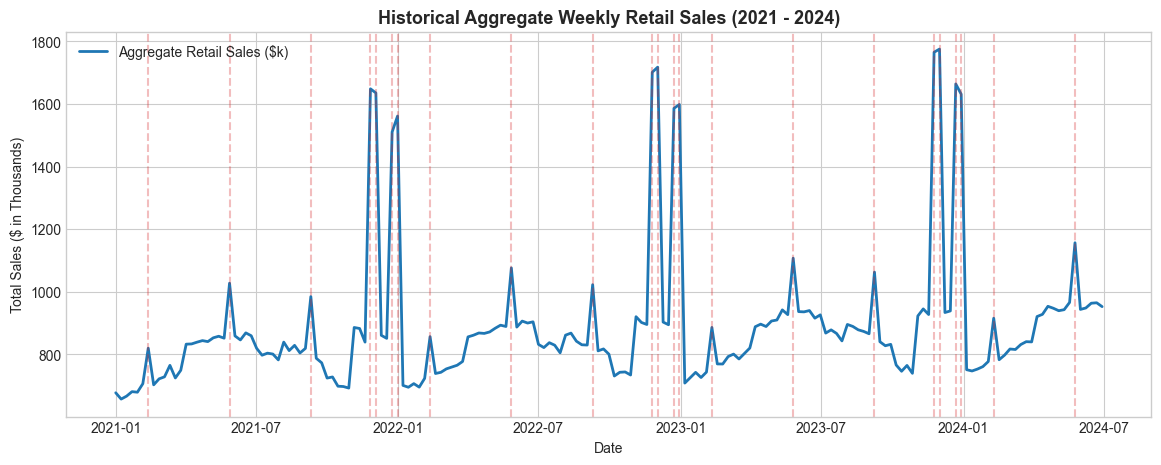

In [3]:
plt.figure(figsize=(14, 5))
weekly_agg = df.groupby("Date")["Weekly_Sales"].sum().reset_index()
plt.plot(weekly_agg["Date"], weekly_agg["Weekly_Sales"] / 1e3, color="#1f77b4", lw=2, label="Aggregate Retail Sales ($k)")
holidays = df[df["IsHoliday"] == 1]["Date"].unique()
for h in holidays:
    plt.axvline(pd.to_datetime(h), color="#d62728", linestyle="--", alpha=0.3)
plt.title("Historical Aggregate Weekly Retail Sales (2021 - 2024)", fontsize=13, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Total Sales ($ in Thousands)")
plt.legend()
plt.show()

## 2. Time-Based Feature Engineering

In [4]:
df_feat, feature_cols = prepare_feature_matrix(df)
print(f"Total engineered features: {len(feature_cols)}")
print("Sample feature columns:", feature_cols[:10])
print("Processed feature matrix shape:", df_feat.shape)

Total engineered features: 57
Sample feature columns: ['Store_ID', 'Store_Size', 'Dept_ID', 'IsHoliday', 'Markdown_Discount', 'Promotional_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment_Rate']
Processed feature matrix shape: (3930, 60)


## 3. Chronological Out-of-Time Train/Validation/Test Split

In [5]:
df_train, df_val, df_test = chronological_split(df_feat, train_ratio=0.70, val_ratio=0.15)
X_train, y_train = df_train[feature_cols], df_train["Weekly_Sales"]
X_val, y_val = df_val[feature_cols], df_val["Weekly_Sales"]
X_test, y_test = df_test[feature_cols], df_test["Weekly_Sales"]

print(f"Train samples: {len(df_train)} | {df_train['Date'].min().date()} to {df_train['Date'].max().date()}")
print(f"Val samples:   {len(df_val)}   | {df_val['Date'].min().date()} to {df_val['Date'].max().date()}")
print(f"Test samples:  {len(df_test)}  | {df_test['Date'].min().date()} to {df_test['Date'].max().date()}")

Train samples: 2730 | 2021-12-31 to 2023-09-22
Val samples:   600   | 2023-09-29 to 2024-02-09
Test samples:  600  | 2024-02-16 to 2024-06-28


## 4. Multi-Model Training & Benchmark Comparison

In [6]:
registry = get_model_registry()
results = []
test_predictions = {}

for name, model in registry.items():
    model.fit(X_train, y_train)
    y_pred = np.maximum(0, model.predict(X_test))
    test_predictions[name] = y_pred
    
    m = compute_metrics(y_test, y_pred)
    m["Model"] = name
    results.append(m)

results_df = pd.DataFrame(results)[["Model", "MAE ($)", "RMSE ($)", "MAPE (%)", "WAPE (%)", "R2 Score"]]
results_df = results_df.sort_values(by="WAPE (%)").reset_index(drop=True)
display(results_df.style.highlight_min(subset=["MAE ($)", "RMSE ($)", "WAPE (%)"], color="#c7e9c0"))

,Model,MAE ($),RMSE ($),MAPE (%),WAPE (%),R2 Score
0,Random Forest,1369.860000,2161.700000,4.800000,4.500000,0.992300
1,XGBoost Regressor,1384.250000,2098.710000,4.860000,4.550000,0.992800
2,LightGBM Regressor,1519.410000,2483.270000,5.250000,4.990000,0.989900
3,Ridge Regression,1650.420000,2327.220000,7.880000,5.430000,0.991100
4,Seasonal Lag-52,1738.850000,2661.810000,5.950000,5.720000,0.988400
5,Rolling 4W Moving Avg,1996.760000,3474.410000,6.610000,6.560000,0.980200
6,Naive Lag-1,2417.930000,4075.670000,8.100000,7.950000,0.972700


## 5. Forecast Visualizations & Residual Diagnostics

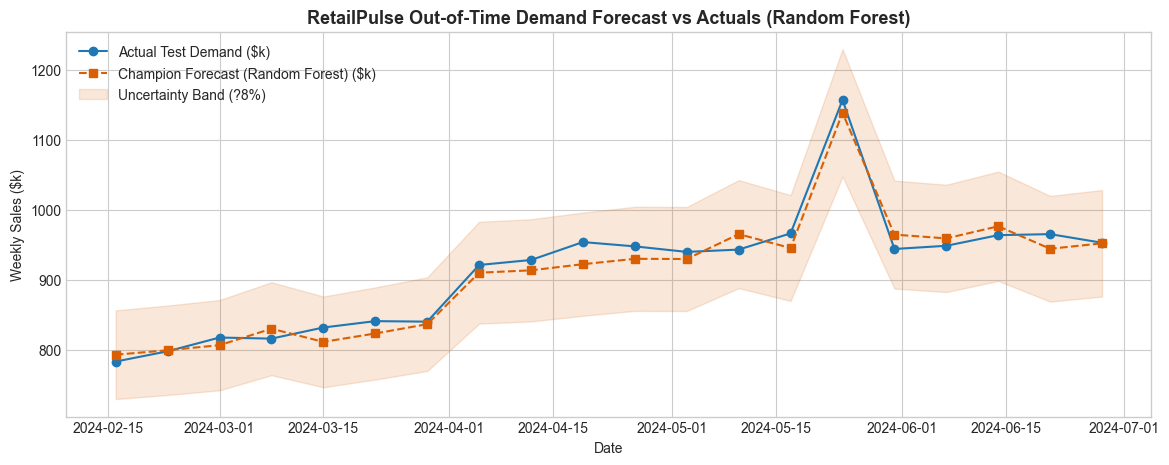

In [7]:
best_model_name = results_df.iloc[0]["Model"]
df_test_eval = df_test.copy()
df_test_eval["Predicted_Sales"] = test_predictions[best_model_name]

test_agg = df_test_eval.groupby("Date").agg({"Weekly_Sales": "sum", "Predicted_Sales": "sum"}).reset_index()

plt.figure(figsize=(14, 5))
plt.plot(test_agg["Date"], test_agg["Weekly_Sales"] / 1e3, label="Actual Test Demand ($k)", color="#1f77b4", marker="o")
plt.plot(test_agg["Date"], test_agg["Predicted_Sales"] / 1e3, label=f"Champion Forecast ({best_model_name}) ($k)", color="#d95f02", linestyle="--", marker="s")
plt.fill_between(test_agg["Date"], (test_agg["Predicted_Sales"]*0.92)/1e3, (test_agg["Predicted_Sales"]*1.08)/1e3, color="#d95f02", alpha=0.15, label="Uncertainty Band (?8%)")
plt.title(f"RetailPulse Out-of-Time Demand Forecast vs Actuals ({best_model_name})", fontsize=13, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Weekly Sales ($k)")
plt.legend()
plt.show()

## 6. Business Insights & Dynamic Safety Stock Calculation

In [8]:
dept_summary = df_test_eval.groupby("Dept_ID").agg(
    Avg_Weekly_Sales=("Weekly_Sales", "mean"),
    Std_Weekly_Sales=("Weekly_Sales", "std"),
    Forecasted_Demand=("Predicted_Sales", "mean")
).reset_index()

lead_time_weeks = 2
z_score = 1.645 # 95% SLA

dept_summary["Safety_Stock_Buffer ($)"] = (z_score * dept_summary["Std_Weekly_Sales"] * np.sqrt(lead_time_weeks)).round(2)
dept_summary["Reorder_Point_ROP ($)"] = ((dept_summary["Avg_Weekly_Sales"] * lead_time_weeks) + dept_summary["Safety_Stock_Buffer ($)"]).round(2)

dept_names = {1: "Electronics", 2: "Apparel", 3: "Grocery", 4: "Home & Garden", 5: "Toys", 6: "Health & Beauty"}
dept_summary["Department"] = dept_summary["Dept_ID"].map(dept_names)

print("Inventory Buffer & Reorder Point (ROP) Policy Summary (95% SLA):")
display(dept_summary[["Dept_ID", "Department", "Avg_Weekly_Sales", "Forecasted_Demand", "Safety_Stock_Buffer ($)", "Reorder_Point_ROP ($)"]])

Inventory Buffer & Reorder Point (ROP) Policy Summary (95% SLA):


,Dept_ID,Department,Avg_Weekly_Sales,Forecasted_Demand,Safety_Stock_Buffer ($),Reorder_Point_ROP ($)
0,1,Electronics,30685.1464,30658.369620,39955.40,101325.69
1,2,Apparel,26968.1087,26478.687485,35971.59,89907.81
2,3,Grocery,62529.8249,62292.026211,82293.70,207353.35
3,4,Home & Garden,24634.2786,24107.357288,37045.48,86314.04
4,5,Toys,14005.9936,14302.731001,18418.99,46430.98
5,6,Health & Beauty,23702.0180,23607.916110,31242.72,78646.76
